# 02. LangChain 제품 계층: Framework vs Runtime vs Harness

> LangChain 생태계는 **Framework(프로토타입) → Runtime(제어) → Harness(완성된 에이전트)** 의 3계층으로 나뉘어요. 각 계층이 푸는 문제와 선택 기준을 비교해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. LangChain(Framework), LangGraph(Runtime), Deep Agents(Harness) 세 계층의 역할을 구분할 수 있어요
2. 각 계층이 어떤 문제를 해결하기 위해 만들어졌는지 설명할 수 있어요
3. 동일한 목표(날씨 에이전트)를 세 가지 방식으로 구현하고 차이점을 비교할 수 있어요
4. 실제 프로젝트에서 어느 계층을 선택해야 할지 판단 기준을 갖출 수 있어요

## 사전 지식

- 이전 노트북 `01-LangChain-V1-Overview.ipynb`: V1 철학 변화, `init_chat_model`, `create_agent`
- Python 함수 데코레이터 기본 이해
- LLM 도구 호출(Tool Calling) 개념

## LangChain 제품 계층이란?

LangChain 생태계는 **세 가지 독립적이면서도 상호 연결된 계층**으로 이루어져 있어요. 각 계층은 서로 다른 수준의 추상화를 제공하고, 서로 다른 문제를 해결해요.

### 왜 세 가지 계층이 필요할까요?

에이전트를 개발할 때 겪는 고민을 생각해봐요:

- **"빠르게 프로토타입을 만들고 싶다"** → 높은 추상화가 필요해요
- **"복잡한 상태를 관리하고, 오류 복구와 Human-in-the-Loop를 구현해야 한다"** → 저수준 제어가 필요해요  
- **"코드 에디터처럼 파일시스템을 다루고, 서브에이전트를 띄우는 실제 에이전트가 필요하다"** → 완전한 하네스가 필요해요

LangChain은 이 세 가지 요구사항 각각을 위한 계층을 제공해요.

> 🔑 **핵심 개념**: 세 계층은 **선택지**예요, 의무적인 단계가 아니에요. 프로젝트 복잡도에 따라 적절한 계층을 선택하거나, 조합해서 사용할 수 있어요.

### 비유로 이해하기: 요리와 비교해볼까요?

세 계층을 요리에 비유하면 이해가 쉬워요:

| 계층 | 요리 비유 | 설명 |
|------|-----------|------|
| **LangChain Framework** | 밀키트(Meal Kit) | 재료와 레시피가 준비되어 있어요. 순서대로 따라하면 요리가 완성돼요. |
| **LangGraph Runtime** | 주방 도구 세트 | 칼, 도마, 프라이팬 등 개별 도구를 직접 선택해서 나만의 레시피를 만들어요. |
| **Deep Agents Harness** | 완전 자동화 주방 | 냉장고 관리, 레시피 검색, 조리까지 주방 전체가 시스템으로 돌아가요. |

밀키트로 시작해서, 더 세밀한 조리가 필요하면 직접 도구를 쓰고, 대규모 자동화가 필요하면 자동화 주방을 도입하는 거예요.

## 전체 아키텍처

```mermaid
flowchart TB
    subgraph HA["Deep Agents (Harness) — 배터리 포함, 완전한 에이전트 환경"]
        direction TB
        H1["write_todos<br>할 일 관리"]
        H2["filesystem<br>파일 읽기/쓰기"]
        H3["subagents<br>서브에이전트 위임"]
        H4["code_execution<br>코드 실행"]
        H5["HITL<br>사람 승인"]
        H6["context<br>컨텍스트 압축"]
    end

    subgraph RT["LangGraph (Runtime) — 저수준 오케스트레이션 엔진"]
        direction TB
        R1["StateGraph<br>상태 그래프"]
        R2["Checkpointer<br>체크포인트"]
        R3["Streaming<br>스트리밍"]
        R4["interrupt<br>Human-in-the-Loop"]
    end

    subgraph FW["LangChain (Framework) — 통합 + 추상화 레이어"]
        direction TB
        F1["init_chat_model<br>통합 모델 초기화"]
        F2["create_agent<br>에이전트 생성"]
        F3["@tool<br>도구 정의"]
        F4["100+ 통합<br>(OpenAI, Anthropic...)"]
    end

    HA --> RT
    RT --> FW
    FW --> LLM["LLM 공급자<br>(OpenAI, Anthropic, Google...)"]

    classDef harness fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef runtime fill:#cce5ff,stroke:#007bff,color:#004085
    classDef framework fill:#d4edda,stroke:#28a745,color:#155724
    classDef llm fill:#fff3cd,stroke:#ffc107,color:#856404

    class H1,H2,H3,H4,H5,H6 harness
    class R1,R2,R3,R4 runtime
    class F1,F2,F3,F4 framework
    class LLM llm
```

### 세 계층 한눈에 비교

| 계층 | 제품 | 추상화 수준 | 주요 특징 | 선택 시점 |
|------|------|------------|----------|----------|
| **Framework** | LangChain | 높음 | 통합, 도구, `create_agent` | 빠른 프로토타입, 표준 에이전트 |
| **Runtime** | LangGraph | 낮음 | `StateGraph`, 체크포인트, HITL | 복잡한 워크플로우, 세밀한 제어 |
| **Harness** | Deep Agents | 최고 | 파일시스템, 서브에이전트, 6가지 기능 | 실제 코딩 에이전트, 장기 실행 태스크 |

## 1. 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 읽어와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# 공용 도구 정의: 세 계층 비교에서 동일하게 사용해요
# ---------------------------------------------------
# @tool 데코레이터로 LLM이 호출할 수 있는 도구를 정의해요
from langchain.tools import tool


@tool
def get_weather(city: str) -> str:
    """특정 도시의 날씨를 조회해요.

    Args:
        city: 날씨를 알고 싶은 도시명
    """
    # 실제 구현에서는 OpenWeatherMap 등의 API를 호출해요
    # 여기서는 비교 목적을 위해 시뮬레이션 데이터를 반환해요
    weather_data = {
        "서울": "맑음, 22°C, 습도 45%",
        "부산": "흐림, 18°C, 습도 70%",
        "제주": "비, 16°C, 습도 85%",
    }
    return weather_data.get(city, f"{city}의 날씨 정보를 찾을 수 없어요.")


print("도구 정의 완료:", get_weather.name)

도구 정의 완료: get_weather


## 2. 계층 1 — LangChain Framework

LangChain Framework는 **통합(Integration) + 추상화(Abstraction)** 레이어예요.

### LangChain이 해결하는 문제

- OpenAI, Anthropic, Google 등 수십 개의 모델 공급자가 각각 다른 API를 가지고 있어요
- 벡터 스토어, 리트리버, 문서 로더도 모두 다른 인터페이스를 가지고 있어요
- LangChain은 이것들을 **하나의 통일된 인터페이스**로 추상화해요

### LangChain의 역할

| 기능 | 예시 |
|------|----- |
| 모델 통합 | `init_chat_model("openai:gpt-4o-mini")` |
| 도구 정의 | `@tool` 데코레이터 |
| 에이전트 생성 | `create_agent(model, tools, system_prompt)` |
| 100+ 통합 | OpenAI, Anthropic, FAISS, Pinecone... |

> 🎯 **강의 포인트**: `create_agent`는 내부적으로 LangGraph `StateGraph`를 사용해요. 하지만 학생은 그 내부를 알 필요가 없어요. 이것이 추상화의 핵심이에요 — 복잡성을 숨기고, 중요한 것만 노출해요.

> 🔑 **핵심 개념**: LangChain Framework는 에이전트를 **빠르게 시작**하기 위한 레이어예요. 복잡한 상태 관리나 세밀한 제어가 필요하지 않다면, 이 레이어에서 멈춰도 충분해요.

In [3]:
# ---------------------------------------------------
# 계층 1: LangChain Framework로 날씨 에이전트 구현
# ---------------------------------------------------
# create_agent: V1 표준 에이전트 생성 함수
# 내부적으로 LangGraph를 사용하지만, 개발자는 몰라도 돼요
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

# 통합 모델 초기화 - 공급자를 문자열로 지정해요
model = init_chat_model("openai:gpt-4o-mini")

# 에이전트 생성: 모델 + 도구 + 시스템 프롬프트
# LangChain이 내부적으로 모든 복잡성을 처리해줘요
langchain_agent = create_agent(
    model=model,
    tools=[get_weather],  # 위에서 정의한 날씨 도구
    system_prompt="당신은 날씨 정보를 제공하는 어시스턴트예요. 도구를 사용해서 정확한 정보를 알려주세요.",
)

# 에이전트 실행
result = langchain_agent.invoke(
    {"messages": [HumanMessage(content="서울 날씨 알려줘")]}
)

# === LangChain Framework 결과 ===
print(result["messages"][-1].content)

서울의 현재 날씨는 맑고, 기온은 22도이며 습도는 45%입니다.


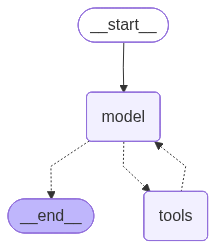

In [4]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: LLM이 날씨 질문을 받아 도구 호출 여부를 결정해요
# tools 노드: get_weather 도구를 실행해요
# 조건부 엣지: tool_call이 있으면 tools, 없으면 END로 분기해요
from IPython.display import Image, display
display(Image(langchain_agent.get_graph().draw_mermaid_png()))

### LangChain Framework 요약

위 코드를 보면, 단 몇 줄로 도구를 사용하는 에이전트를 만들었어요. 이것이 LangChain Framework의 강점이에요:
- 복잡한 설정 없이 빠르게 시작
- 모든 공급자에 통일된 인터페이스

하지만 **한계**도 있어요: 에이전트가 실패했을 때 어떻게 복구할지, 중간 상태를 저장하려면 어떻게 해야 하는지, 사람이 개입하려면 어떻게 해야 하는지... 이런 제어가 필요하면 다음 레이어인 LangGraph가 필요해요.

> 💡 **실무 팁**: 실제 프로젝트에서는 `create_agent`로 시작해서 잘 동작하는지 확인한 뒤, 더 세밀한 제어가 필요한 부분만 LangGraph로 전환하는 **점진적 마이그레이션** 전략이 효과적이에요.

## 3. 계층 2 — LangGraph Runtime

LangGraph는 **저수준 오케스트레이션 엔진**이에요. LangChain Framework가 내부적으로 사용하는 바로 그 엔진이에요.

### LangGraph가 해결하는 문제

- **상태 지속성**: 긴 대화나 복잡한 작업에서 중간 상태를 저장하고 복원해야 해요
- **오류 복구**: 특정 단계가 실패했을 때 그 지점부터 재시작해야 해요
- **Human-in-the-Loop**: 특정 단계에서 사람의 승인을 기다려야 해요
- **복잡한 조건 분기**: 단순한 선형 흐름이 아닌 복잡한 워크플로우가 필요해요

### LangGraph의 핵심 개념

```mermaid
flowchart LR
    S(["START"]) --> N1["노드 1<br>(Node)"]  
    N1 -->|"엣지 (Edge)"| N2["노드 2"]
    N2 -->|"조건부 엣지<br>(Conditional Edge)"| N3["노드 3"]
    N2 -->|"조건부 엣지"| N4["노드 4"]
    N3 --> E(["END"])
    N4 --> E

    subgraph ST["State (상태)"]
        direction TB
        ST1["messages: list"]
        ST2["other_fields: any"]
    end

    N1 -.->|"상태 읽기/쓰기"| ST
    N2 -.->|"상태 읽기/쓰기"| ST

    classDef node fill:#cce5ff,stroke:#007bff,color:#004085
    classDef state fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef terminal fill:#d4edda,stroke:#28a745,color:#155724

    class N1,N2,N3,N4 node
    class ST,ST1,ST2 state
    class S,E terminal
```

| 개념 | 설명 |
|------|------|
| **StateGraph(상태 그래프)** | 노드와 엣지로 이루어진 실행 그래프예요 |
| **State(상태)** | 그래프 전체에서 공유하는 데이터 컨테이너예요 |
| **Node(노드)** | 상태를 읽고 수정하는 함수예요 |
| **Edge(엣지)** | 노드 간 연결이에요 (조건부도 가능) |
| **Checkpointer(체크포인터)** | 각 실행 단계를 저장해서 복구와 Time Travel을 가능하게 해요 |

> 🎯 **강의 포인트**: LangGraph는 에이전트 실행을 **그래프**로 표현해요. **지하철 노선도**를 떠올려보세요 — 역(노드)에서 작업을 하고, 노선(엣지)을 따라 다음 역으로 이동해요. 환승역(조건부 엣지)에서는 상황에 따라 다른 노선으로 갈아탈 수 있어요. 이 구조 덕분에 복잡한 분기와 루프가 가능해요.

> ⚠️ **자주 하는 실수**: LangGraph를 "사용해야만 하는 것"으로 오해하는 경우가 있어요. LangChain `create_agent`로 충분한 단순한 에이전트에도 StateGraph를 직접 구성하려 하면 오히려 복잡해져요. 복잡성이 필요할 때 사용하세요.

In [5]:
# ---------------------------------------------------
# 계층 2: LangGraph Runtime으로 날씨 에이전트 구현
# ---------------------------------------------------
# StateGraph를 직접 구성해서 더 세밀한 제어를 할 수 있어요
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


# 상태(State) 정의: 그래프 전체에서 공유하는 데이터
# add_messages: 메시지를 덮어쓰지 않고 누적(append)하는 리듀서
class WeatherState(TypedDict):
    messages: Annotated[list, add_messages]  # 대화 히스토리 누적


# 모델에 도구를 바인딩해요
# bind_tools: LLM이 어떤 도구를 사용할 수 있는지 알려줘요
tools = [get_weather]
model_with_tools = init_chat_model("openai:gpt-4o-mini").bind_tools(tools)


# 노드(Node) 정의: 상태를 입력받아 수정된 상태를 반환하는 함수
def call_model(state: WeatherState) -> dict:
    """LLM을 호출하고 응답을 상태에 추가해요."""
    # 현재 메시지 목록을 LLM에 전달해요
    response = model_with_tools.invoke(state["messages"])
    # 반환값의 messages가 기존 목록에 누적(add_messages 리듀서)
    return {"messages": [response]}


# 그래프 구성
workflow = StateGraph(WeatherState)

# 노드 추가
workflow.add_node("call_model", call_model)  # LLM 호출 노드
workflow.add_node("tools", ToolNode(tools))  # 도구 실행 노드

# 엣지 추가: 실행 흐름 정의
workflow.add_edge(START, "call_model")  # 시작 → LLM 호출
workflow.add_conditional_edges(         # LLM 응답에 따라 분기
    "call_model",
    tools_condition,  # 도구 호출이 있으면 tools로, 없으면 END로
)
workflow.add_edge("tools", "call_model")  # 도구 실행 후 다시 LLM으로

# 그래프 컴파일
langgraph_agent = workflow.compile()

# LangGraph 에이전트 구성 완료

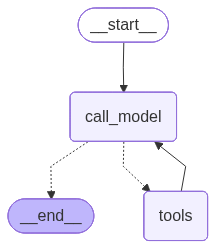

In [6]:
# 그래프 흐름: START → call_model → tools → call_model → ... → END
# call_model 노드: LLM이 사용자 메시지를 받아 응답을 생성해요
# tools 노드: tool_call이 있으면 도구를 실행해요
# 조건부 엣지: tool_call 유무에 따라 tools 또는 END로 분기해요
# ---------------------------------------------------
# LangGraph 에이전트 실행
# ---------------------------------------------------
from langchain.messages import HumanMessage
from IPython.display import Image, display

# 그래프 구조 시각화
# 그래프 구조:
display(Image(langgraph_agent.get_graph().draw_mermaid_png()))

In [7]:
# ---------------------------------------------------
# LangGraph 에이전트 실행 - 스트리밍 방식
# ---------------------------------------------------
# stream_mode="updates": 각 노드 실행 결과를 실시간으로 볼 수 있어요
inputs = {"messages": [HumanMessage(content="서울 날씨 알려줘")]}

# === LangGraph Runtime 결과 ===

for chunk in langgraph_agent.stream(inputs, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()


--- 노드: call_model ---
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_QKci0lcrB1mygZlN9VBdK29K)
 Call ID: call_QKci0lcrB1mygZlN9VBdK29K
  Args:
    city: 서울

--- 노드: tools ---
================================= Tool Message =================================
Name: get_weather

맑음, 22°C, 습도 45%

--- 노드: call_model ---
================================== Ai Message ==================================

서울의 날씨는 맑으며, 기온은 22°C, 습도는 45%입니다.


### LangGraph Runtime 요약

LangChain Framework 버전보다 코드가 길어졌지만, **무슨 일이 일어나는지 완전히 제어**할 수 있어요:

- 어떤 노드가 실행되는지 명시적으로 확인할 수 있어요
- 중간에 체크포인터를 추가해서 상태를 저장할 수 있어요
- `interrupt`를 사용해서 특정 단계에서 사람의 승인을 받을 수 있어요

이 교재에서 Part 2~4에 걸쳐 LangGraph를 깊이 배울 거예요. 지금은 "더 세밀한 제어를 위한 엔진"이라는 개념만 이해해도 충분해요.

> ⚠️ **자주 하는 실수**: LangGraph 코드가 길어 보여서 "어렵다"고 느낄 수 있어요. 하지만 긴 코드의 대부분은 **그래프 구성(노드 추가, 엣지 연결)** 이에요. 한 번 패턴을 익히면 반복적으로 적용할 수 있어요.

그럼 LangGraph보다 더 높은 수준의 추상화가 필요한 경우는 어떤 경우일까요? 파일을 읽고 쓰고, 서브에이전트를 띄우고, 코드를 실행하는 **실제 시스템과 상호작용하는 에이전트**가 필요할 때예요. 이것이 바로 다음에 살펴볼 Deep Agents의 영역이에요.

## 4. 계층 3 — Deep Agents Harness

Deep Agents는 **배터리 포함(batteries-included)** 에이전트 하네스예요.

### Deep Agents가 해결하는 문제

Claude Code, Devin, GitHub Copilot Workspace 같은 코딩 에이전트를 상상해봐요. 이런 에이전트는:

- 파일을 읽고 수정해야 해요
- 할 일 목록을 관리해야 해요
- 복잡한 태스크를 서브에이전트에 위임해야 해요
- 코드를 직접 실행해야 해요
- 장기간 실행 중에 사람의 승인을 받아야 해요
- 긴 컨텍스트를 압축해서 관리해야 해요

이것들을 LangGraph로 직접 구현하는 것은 복잡해요. Deep Agents는 이런 **공통 패턴을 미리 구현**해서 제공해요.

### Deep Agents의 6가지 Harness 기능

| 기능 | 설명 | 예시 |
|------|------|------|
| **Planning** | 할 일 목록 자동 생성 및 관리 | `write_todos(tasks)` |
| **Filesystem** | 파일 읽기/쓰기/수정 | `read_file(path)`, `write_file(path, content)` |
| **Subagents** | 전문화된 서브에이전트에 위임 | `create_subagent(instructions)` |
| **Context** | 장기 대화 컨텍스트 압축 | 자동 요약 및 압축 |
| **Code Execution** | 코드 직접 실행 | Python, Bash 실행 환경 |
| **HITL** | 중요한 작업 전 사람 승인 요청 | `request_approval(action)` |

> 🔑 **핵심 개념**: Deep Agents는 LangChain과 LangGraph **위에** 구축되어 있어요. 즉, Deep Agents를 사용하면 하위 레이어의 기능도 모두 사용할 수 있어요. 단지 더 높은 수준의 추상화를 추가로 제공하는 거예요.

> 💡 **실무 팁**: 코드 에디터 플러그인, 자동화 에이전트, 데이터 분석 에이전트처럼 **실제 시스템과 상호작용**해야 하는 에이전트라면 Deep Agents를 고려해보세요. 단순한 Q&A 챗봇에는 과도해요.

### Deep Agents 코드 패턴 (참고용 pseudocode)

Deep Agents의 실제 사용 패턴을 간단히 살펴봐요. 실제 사용은 Part 10에서 자세히 다뤄요.

```python
# 실제 Deep Agents 코드 패턴 (Part 10에서 배워요)
from langchain.agents import create_deep_agent

# 하네스 기능을 갖춘 에이전트 생성
deep_agent = create_deep_agent(
    model=init_chat_model("openai:gpt-4o-mini"),
    harness=[
        "planning",       # 할 일 목록 자동 관리
        "filesystem",     # 파일 읽기/쓰기
        "subagents",      # 서브에이전트 위임
        "code_execution", # 코드 실행
    ],
    system_prompt="당신은 날씨 데이터를 분석하고 보고서를 작성하는 에이전트예요.",
)

# 복잡한 태스크 실행
result = deep_agent.run(
    "서울, 부산, 제주의 날씨를 조사하고"
    " weather_report.md 파일에 보고서를 작성해줘"
)
# Deep Agents는 자동으로:
# 1. 할 일 목록 생성 (도시별 날씨 조회, 보고서 작성)
# 2. 각 도시 날씨 도구 호출
# 3. 수집된 데이터를 파일에 작성
# 4. 완료 보고
```

In [8]:
# ---------------------------------------------------
# Deep Agents 핵심 아이디어: Planning + Filesystem 시뮬레이션
# ---------------------------------------------------
# Deep Agents의 핵심 아이디어인 할 일 관리와 파일 작성을
# 직접 구현해서 개념을 이해해봐요
import json
from datetime import datetime


def simulate_deep_agent_planning(task: str, sub_tasks: list[str]) -> dict:
    """Deep Agents의 Planning 하네스를 시뮬레이션해요.
    
    Args:
        task: 메인 태스크 설명
        sub_tasks: 서브태스크 목록
    
    Returns:
        할 일 목록 딕셔너리
    """
    todos = {
        "task": task,
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "sub_tasks": [
            {"id": i + 1, "description": t, "status": "pending"}
            for i, t in enumerate(sub_tasks)
        ],
    }
    return todos


def simulate_task_completion(todos: dict, task_id: int) -> dict:
    """특정 서브태스크를 완료 처리해요."""
    for task in todos["sub_tasks"]:
        if task["id"] == task_id:
            task["status"] = "completed"
    return todos


# Planning 하네스 시뮬레이션
todos = simulate_deep_agent_planning(
    task="날씨 보고서 작성",
    sub_tasks=[
        "서울 날씨 조회",
        "부산 날씨 조회",
        "제주 날씨 조회",
        "보고서 파일 작성",
    ],
)

# === Deep Agents Planning 시뮬레이션 ===
print(json.dumps(todos, ensure_ascii=False, indent=2))

# 태스크 1, 2 완료 처리 시뮬레이션
todos = simulate_task_completion(todos, 1)
todos = simulate_task_completion(todos, 2)

# 서울/부산 날씨 조회 완료 후 상태:
for task in todos["sub_tasks"]:
    status_icon = "✓" if task["status"] == "completed" else "○"
    print(f"  {status_icon} [{task['id']}] {task['description']} ({task['status']})")

{
  "task": "날씨 보고서 작성",
  "created_at": "2026-05-07 12:58:42",
  "sub_tasks": [
    {
      "id": 1,
      "description": "서울 날씨 조회",
      "status": "pending"
    },
    {
      "id": 2,
      "description": "부산 날씨 조회",
      "status": "pending"
    },
    {
      "id": 3,
      "description": "제주 날씨 조회",
      "status": "pending"
    },
    {
      "id": 4,
      "description": "보고서 파일 작성",
      "status": "pending"
    }
  ]
}
  ✓ [1] 서울 날씨 조회 (completed)
  ✓ [2] 부산 날씨 조회 (completed)
  ○ [3] 제주 날씨 조회 (pending)
  ○ [4] 보고서 파일 작성 (pending)


### 실제 `create_deep_agent`로 같은 흐름 실행하기

위 셀은 Deep Agents가 내부에서 해주는 Planning/Filesystem 흐름을 직접 흉내낸 예시예요. 실제 SDK에서는 `create_deep_agent`로 에이전트를 만들면 `write_todos`와 `write_file` 같은 하네스 도구가 기본으로 포함돼요.

아래 코드는 앞에서 만든 `get_weather` 도구만 추가하고, 에이전트에게 **TODO 작성 → 도시별 날씨 조회 → `/weather_report.md` 파일 작성**을 맡기는 실제 Deep Agents 예제예요.

> 실행 전: `deepagents`, `langchain-openai` 설치와 `OPENAI_API_KEY` 설정이 필요해요.


In [13]:
# ---------------------------------------------------
# 실제 Deep Agents SDK: create_deep_agent로 Planning + Filesystem 실행
# ---------------------------------------------------
# Deep Agents에는 write_todos, ls/read_file/write_file/edit_file 같은
# 하네스 도구가 기본 포함되어 있어요. 우리는 날씨 도구만 추가해요.
from deepagents import create_deep_agent
from langchain.messages import HumanMessage


deep_agent = create_deep_agent(
    model="openai:gpt-4o-mini",  # 앞선 예제와 같은 OpenAI 모델 사용
    tools=[get_weather],          # 우리가 정의한 도구 + Deep Agents 기본 도구들
    system_prompt=(
        "당신은 날씨 보고서를 작성하는 Deep Agent예요. "
        "복잡한 작업을 받으면 반드시 먼저 write_todos로 할 일을 만들고 관리하세요. "
        "get_weather 도구로 도시별 날씨를 조회한 뒤, "
        "최종 보고서를 /Users/mhso/working/lecture/llm/langchain-llm/03_langgraph-agents/01_Introduction/eather_report.md 파일에 작성하세요. "
        "마지막 답변에는 완료한 TODO와 파일 경로를 한국어로 요약하세요."
    ),
)

deep_agent_result = deep_agent.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "서울, 부산, 제주의 날씨를 조회해서 날씨 보고서를 작성해줘. "
                    "진행 상황은 TODO로 관리하고, 보고서는 /Users/mhso/working/lecture/llm/langchain-llm/03_langgraph-agents/01_Introduction/weather_report.md에 저장해줘."
                )
            )
        ]
    }
)

print("=== 실제 Deep Agents TODO 상태 ===")
todos = deep_agent_result.get("todos", [])
if todos:
    for i, todo in enumerate(todos, 1):
        status = todo.get("status", "unknown")
        status_icon = "✓" if status == "completed" else "○"
        print(f"  {status_icon} [{i}] {todo.get('content', todo)} ({status})")
else:
    print("  TODO 상태가 결과에 포함되지 않았어요. 아래 최종 응답을 확인해보세요.")

report = deep_agent_result.get("files", {}).get("/Users/mhso/working/lecture/llm/langchain-llm/03_langgraph-agents/01_Introduction/weather_report.md")
if report:
    print("\n=== ./weather_report.md ===")
    print(report.get("content", ""))

print("\n=== 최종 응답 ===")
print(deep_agent_result["messages"][-1].content)

=== 실제 Deep Agents TODO 상태 ===
  ✓ [1] 서울의 날씨 조회 (completed)
  ✓ [2] 부산의 날씨 조회 (completed)
  ✓ [3] 제주의 날씨 조회 (completed)
  ✓ [4] 날씨 보고서 작성 (completed)
  ✓ [5] 날씨 보고서를 파일에 저장 (completed)

=== ./weather_report.md ===
# 날씨 보고서

## 서울
- 날씨: 맑음
- 기온: 22°C
- 습도: 45%

## 부산
- 날씨: 흐림
- 기온: 18°C
- 습도: 70%

## 제주
- 날씨: 비
- 기온: 16°C
- 습도: 85%

=== 최종 응답 ===
[{'type': 'text', 'text': '모든 작업이 완료되었습니다. 날씨 보고서는 다음과 같이 작성되었습니다:\n\n- **서울**: 맑음, 22°C, 습도 45%\n- **부산**: 흐림, 18°C, 습도 70%\n- **제주**: 비, 16°C, 습도 85%\n\n보고서는 아래 경로에 저장되었습니다:\n**/Users/mhso/working/lecture/llm/langchain-llm/03_langgraph-agents/01_Introduction/weather_report.md** \n\n진행 상황은 모두 완료되었습니다.', 'annotations': [], 'id': 'msg_0dc6d07c9f58b9f70069fc0e68cf94819591f3218926f97bce'}]


## 5. 세 계층 비교: 언제 무엇을 선택할까요?

### Feature Comparison

| 기능 | LangChain Framework | LangGraph Runtime | Deep Agents Harness |
|------|:-------------------:|:-----------------:|:-------------------:|
| 빠른 시작 | ✅ 매우 쉬움 | 보통 | 보통 |
| 상태 지속성 | 기본 지원 | ✅ 완전 제어 | ✅ 자동 관리 |
| 스트리밍 | ✅ 지원 | ✅ 완전 제어 | ✅ 자동 |
| Human-in-the-Loop | 제한적 | ✅ `interrupt` | ✅ 내장 |
| 파일시스템 접근 | 도구로 직접 구현 | 도구로 직접 구현 | ✅ 내장 |
| 서브에이전트 | 제한적 | 수동 구현 | ✅ 내장 |
| 세밀한 제어 | 제한적 | ✅ 완전 제어 | 추상화됨 |
| 학습 곡선 | 낮음 | 보통 | 보통 |

### 선택 가이드

```mermaid
flowchart TD
    Q1{"파일 시스템, 서브에이전트,
    코드 실행이 필요한가요?"}
    Q2{"복잡한 상태 관리, HITL,
    오류 복구가 필요한가요?"}
    A1["Deep Agents Harness<br>배터리 포함 에이전트"]
    A2["LangGraph Runtime<br>저수준 오케스트레이션"]
    A3["LangChain Framework<br>빠른 시작"]

    Q1 -->|Yes| A1
    Q1 -->|No| Q2
    Q2 -->|Yes| A2
    Q2 -->|No| A3

    classDef harness fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef runtime fill:#cce5ff,stroke:#007bff,color:#004085
    classDef framework fill:#d4edda,stroke:#28a745,color:#155724
    classDef question fill:#fff3cd,stroke:#ffc107,color:#856404

    class A1 harness
    class A2 runtime
    class A3 framework
    class Q1,Q2 question
```

> 🎯 **강의 포인트**: 이 교재의 흐름이 바로 이 선택 가이드를 따라요. Part 2~4에서 LangGraph를 배우고, Part 5~6에서 LangChain 에이전트 고급 기능을 배우고, Part 10에서 Deep Agents를 배워요. 계층을 이해하면 교재 전체 구조가 보여요.

> 💡 **실무 팁**: 실제 프로젝트에서는 세 계층을 혼용해요. 예를 들어 Deep Agents로 만든 에이전트 내부에서 LangGraph의 특정 기능이 필요하면 직접 사용할 수 있어요. 계층은 배타적이지 않고 **보완적**이에요.

In [10]:
# ---------------------------------------------------
# 세 계층 비교: 동일한 질문에 대한 응답 비교
# ---------------------------------------------------
# 날씨 에이전트 세 버전의 응답을 비교해봐요
from langchain.messages import HumanMessage

question = "부산 날씨 알려줘"

# 계층 1: LangChain Framework
# ==================================================
# [계층 1] LangChain Framework
# ==================================================
result_fw = langchain_agent.invoke(
    {"messages": [HumanMessage(content=question)]}
)
print(result_fw["messages"][-1].content)
print()

# 계층 2: LangGraph Runtime
# ==================================================
# [계층 2] LangGraph Runtime
# ==================================================
result_rt = langgraph_agent.invoke(
    {"messages": [HumanMessage(content=question)]}
)
print(result_rt["messages"][-1].content)
print()

# 계층 3: Deep Agents는 시뮬레이션으로만 표현
# ==================================================
# [계층 3] Deep Agents Harness (개념적 예시)
# ==================================================
# 실제 Deep Agents는 Part 10에서 배워요.
# 지금은 '파일시스템, 서브에이전트, 코드 실행 등이 내장된 에이전트'로 이해해요.

부산의 현재 날씨는 흐림이며, 기온은 18°C이고 습도는 70%입니다.

부산의 날씨는 흐림이며, 기온은 18도, 습도는 70%입니다.



## 6. 경쟁 프레임워크와의 비교

LangChain 생태계 외에도 에이전트 개발을 위한 다양한 프레임워크가 있어요. 각각의 포지셔닝을 이해하면 기술 선택에 도움이 돼요.

| 프레임워크 | 주요 특징 | LangChain 생태계 대응 |
|------------|----------|----------------------|
| **Vercel AI SDK** | JS/TS 중심, Next.js 통합 | LangChain (Framework 레이어) |
| **CrewAI** | 역할 기반 멀티에이전트 | LangGraph + Supervisor 패턴 |
| **OpenAI Agents SDK** | OpenAI 전용 최적화 | LangChain + LangGraph |
| **Google ADK** | Google Cloud 통합 최적화 | LangChain + LangGraph |
| **LangChain** | 공급자 무관 통합 + 런타임 | 해당 없음 (세 계층 모두 포함) |

> 🔑 **핵심 개념**: LangChain이 경쟁 우위를 가지는 이유는 **공급자 독립성(vendor independence)** 이에요. OpenAI에서 Anthropic 또는 Google 모델로 교체할 때 코드 변경이 최소화돼요.

> 💡 **실무 팁**: 팀이 이미 Next.js 생태계라면 Vercel AI SDK가 자연스럽고, Google Cloud에 deep integration이 필요하면 Google ADK를 고려해볼 수 있어요. 하지만 모델 교체 유연성이 중요하다면 LangChain이 강점을 발휘해요.

In [11]:
# ---------------------------------------------------
# 공급자 독립성 데모: 같은 코드로 다른 모델 사용
# ---------------------------------------------------
# LangChain의 핵심 강점: 모델 공급자를 코드에서 분리
# init_chat_model로 어떤 공급자든 동일한 인터페이스로 사용해요
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

# 지원하는 공급자 목록 (환경 변수에 API 키 필요)
providers = [
    "openai:gpt-4o-mini",          # OpenAI
    # "anthropic:claude-haiku-4-5",  # Anthropic (ANTHROPIC_API_KEY 필요)
    # "google_genai:gemini-2.0-flash", # Google (GOOGLE_API_KEY 필요)
]

question_msg = [HumanMessage(content="안녕! 한 문장으로 자기소개 해줘.")]

for provider_model in providers:
    # 공급자만 다르고, 나머지 코드는 완전히 동일해요!
    current_model = init_chat_model(provider_model)
    response = current_model.invoke(question_msg)
    print(f"[{provider_model}]")
    print(f"  {response.content}")
    print()

# 공급자를 바꿔도 코드는 동일 — LangChain의 핵심 강점!

[openai:gpt-4o-mini]
  안녕하세요! 저는 다양한 정보를 제공하고 도움을 주기 위해 만들어진 AI입니다.



## 7. 실습: 나의 프로젝트에 적합한 계층 선택하기

In [12]:
# ============================================================
# 구현 예시: 시나리오별 적합한 계층 선택
# ============================================================

scenario_a = "LangChain"     # FAQ 챗봇 프로토타입: 빠른 시작과 기본 에이전트에 적합
scenario_b = "Deep Agents"   # 코드 리뷰 에이전트: 파일 시스템, TODO, 서브에이전트가 필요
scenario_c = "LangGraph"     # 결제 전 승인: HITL, 상태 복구, 복잡한 분기에 적합
scenario_d = "LangChain"     # 공급자 교체: init_chat_model 기반 provider 독립성이 장점

# 시나리오 분석 결과:
print(f"  A (FAQ 챗봇 프로토타입): {scenario_a}")
print(f"  B (코드 리뷰 에이전트, 파일 접근): {scenario_b}")
print(f"  C (결제 전 사람 승인): {scenario_c}")
print(f"  D (공급자 독립성): {scenario_d}")


  A (FAQ 챗봇 프로토타입): LangChain
  B (코드 리뷰 에이전트, 파일 접근): Deep Agents
  C (결제 전 사람 승인): LangGraph
  D (공급자 독립성): LangChain


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **LangChain Framework**: 통합 + 추상화 레이어예요. `init_chat_model`, `create_agent`, `@tool`로 빠르게 에이전트를 만들 수 있어요. 공급자 독립성이 핵심 강점이에요.
- **LangGraph Runtime**: 저수준 오케스트레이션 엔진이에요. `StateGraph`, 체크포인터, `interrupt`로 복잡한 워크플로우를 정밀하게 제어할 수 있어요. LangChain Framework가 내부적으로 사용해요.
- **Deep Agents Harness**: 배터리 포함 에이전트 환경이에요. 파일시스템, 서브에이전트, 코드 실행 등 6가지 하네스 기능을 제공해요. 코딩 에이전트처럼 실제 시스템과 상호작용하는 에이전트에 적합해요.
- **계층 관계**: 세 계층은 배타적이지 않고 보완적이에요. Deep Agents는 LangChain과 LangGraph 위에 구축되어 있어요.
- **선택 기준**: 파일시스템/서브에이전트 필요 → Deep Agents, 복잡한 HITL/상태 관리 필요 → LangGraph, 빠른 시작 → LangChain Framework

## 참고: 에이전트 = 모델 + 모델 외부의 모든 것

LangChain의 3계층 위로 갈수록 두꺼워지는 "모델 외부 인프라"를 한 단어로 *harness* 라고 부르기도 합니다 (Martin Fowler, 2026). 이 교재는 그 인프라를 LangGraph·미들웨어·Skills·MCP로 직접 조립합니다. 용어 자체는 부차적이고, 본질은 "어떤 컴포넌트로 무엇을 보강할지"의 선택입니다.

## 다음 노트북 예고

다음 챕터 `02_LangGraph_Basics/01-LangGraph-Python-Basics.ipynb`에서는 **TypedDict, Annotated, add_messages** 를 배워요. LangGraph가 상태(State)를 어떻게 정의하고 관리하는지, Python 타입 시스템을 어떻게 활용하는지 기초부터 탄탄하게 다져봐요.